# Ideal Gas: elastic hard-sphere kinetics in a box

2D hard-sphere gas in a reflecting box: particles start with two opposing beams of speed `v0`, collide elastically, and settle into a Maxwell-Boltzmann speed distribution while exerting measurable pressure on the walls. Physics/collision code lives in `ideal_gas.py` (shared with `Ideal Gas Gravity.ipynb` and `Ideal Gas Orbit.ipynb`, which add external forces and different boundary conditions on top of the same collision kernel).

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import ideal_gas as ig

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ig.configure_ffmpeg()

## Single run: particle motion, pressure trace, and the Maxwell-Boltzmann distribution

In [6]:
n_particles = 20000
dt = 8e-6
t_steps = 510
radius = 0.0005
v0 = 500.0

r = torch.rand((2, n_particles), device=device)
ixr, ixl = r[0] > 0.5, r[0] <= 0.5
v = torch.zeros((2, n_particles), device=device)
v[0][ixr] = -v0
v[0][ixl] = v0

rs, vs, ps = ig.motion(r, v, ts=t_steps, dt=dt, d_cutoff=2 * radius, L=1.0, track_pressure=True)

In [7]:
import torch.nn.functional as F

def smooth(series, kernel_size=21, sigma=5.0):
    kernel = torch.exp(-(torch.arange(kernel_size).float() - kernel_size // 2)**2 / (2 * sigma**2))
    kernel /= kernel.sum()
    return F.conv1d(series.view(1, 1, -1).cpu(), kernel.view(1, 1, -1), padding=kernel_size // 2).view(-1)

smooth_ps = smooth(ps)

# Analytic 2D Maxwell-Boltzmann speed distribution for comparison
v_axis = np.linspace(0, 2000, 1000)
a = 2 / v0**2
fv = a * v_axis * np.exp(-a * v_axis**2 / 2)
bins = np.linspace(0, 1500, 50)

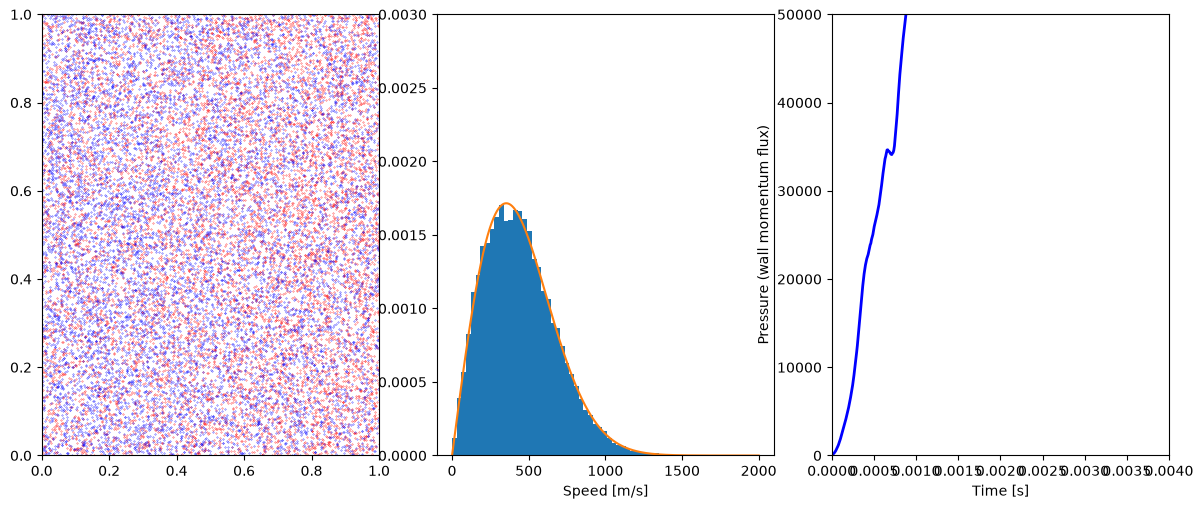

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.tight_layout()

vmin, vmax = 0, 1
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
markersize = 2 * radius * axes[0].get_window_extent().width / (vmax - vmin) * 72. / fig.dpi
red, = axes[0].plot([], [], 'o', color='red', markersize=markersize)
blue, = axes[0].plot([], [], 'o', color='blue', markersize=markersize)

n, _, patches = axes[1].hist(torch.sqrt(torch.sum(vs[0]**2, axis=0)).cpu(), bins=bins, density=True)
axes[1].plot(v_axis, fv)
axes[1].set_ylim(top=0.003)
axes[1].set_xlabel('Speed [m/s]')

axes[2].set_xlim(0, 0.004)
axes[2].set_ylim(0, 50000)
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Pressure (wall momentum flux)')
line, = axes[2].plot([], [], lw=2, color='b')

# Sample every `stride`-th simulation step for the animation -- rendering every
# single timestep is the dominant cost, not the physics itself.
stride = ig.frame_stride(t_steps)
n_frames = t_steps // stride

def animate(frame):
    i = frame * stride
    xred, yred = rs[i][0][ixr].cpu(), rs[i][1][ixr].cpu()
    xblue, yblue = rs[i][0][ixl].cpu(), rs[i][1][ixl].cpu()
    red.set_data(xred, yred)
    blue.set_data(xblue, yblue)
    line.set_data(np.arange(0, i + 1) * dt, smooth_ps[:i + 1].numpy())
    hist, _ = np.histogram(torch.sqrt(torch.sum(vs[i]**2, axis=0)).cpu(), bins=bins, density=True)
    for j, patch in enumerate(patches):
        patch.set_height(hist[j])
    return line, red, blue

ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=50, blit=True)
ani.save(os.path.join(MEDIA, "ideal_gas_pressure.mp4"), writer="ffmpeg", fps=30)
plt.show()

## Pressure vs. initial speed sweep

Runs the same box at a range of initial beam speeds and averages the late-time pressure, to check that pressure grows with temperature (speed) as expected for an ideal gas.

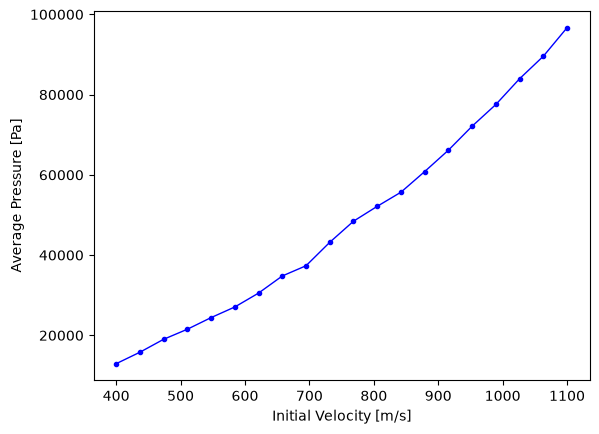

In [5]:
n_particles_sweep = 5000
num_runs = 20
v_runs = np.linspace(400, 1100, num_runs)
p_runs = []

for run, v0_run in enumerate(v_runs):
    print(f"Run {run + 1}/{num_runs}", end='\r')
    r = torch.rand((2, n_particles_sweep), device=device)
    ixr, ixl = r[0] > 0.5, r[0] <= 0.5
    v = torch.zeros((2, n_particles_sweep), device=device)
    v[0][ixr] = -v0_run
    v[0][ixl] = v0_run
    _, _, ps_run = ig.motion(r, v, ts=t_steps, dt=dt, d_cutoff=2 * radius, L=1.0, track_pressure=True)
    p_runs.append(ps_run[-100:].mean().item())

fig, ax = plt.subplots()
ax.plot(v_runs, p_runs, marker='.', color='blue', linewidth=1)
ax.set_xlabel('Initial Velocity [m/s]')
ax.set_ylabel('Average Pressure [Pa]')
fig.savefig(os.path.join(MEDIA, "pressure_vs_speed.png"), dpi=300, bbox_inches='tight')
plt.show()